In [1]:
print('Hello WOrld')

Hello WOrld


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Dataset Meaning
This dataset represents Netflix catalog content. Each row is one title available on Netflix, either a Movie or TV Show. It contains metadata such as title, director, cast, country, date added to Netflix, release year, maturity rating, duration, genres, and description.

Dataset Shape


Rows: 8,807
Columns: 12
Duplicate rows: 0
Duplicate titles: 0
Unique show IDs: 8,807

Main Patterns
Netflix catalog is movie-heavy:

Movie:   6,131 titles, 69.62%
TV Show: 2,676 titles, 30.38%

Most content was added between 2017 and 2021

2017: 1,188
2018: 1,649
2019: 2,016
2020: 1,879
2021: 1,498

The catalog is relatively recent. Median release year is 2017, and 75% of content was released in or after 2013.

Most common ratings:

TV-MA: 3,207
TV-14: 2,160
TV-PG:   863
R:       799
PG-13:   490

Top countries:

United States: 3,689
India:         1,046
United Kingdom: 804
Canada:          445
France:          393
Japan:           318

Top genres/categories:

International Movies:   2,752
Dramas:                 2,427
Comedies:               1,674
International TV Shows: 1,351
Documentaries:            869
Action & Adventure:       859

Movie duration is centered around standard feature length:

Average movie duration: 99.58 minutes
Median movie duration:  98 minutes
Min: 3 minutes
Max: 312 minutes

TV shows are mostly short-running:

1 season: 1,793 shows
2 seasons: 425 shows
3 seasons: 199 shows

Data Quality Issues

Missing values:


director:   2,634 missing, 29.91%
country:      831 missing, 9.44%
cast:         825 missing, 9.37%
date_added:    10 missing, 0.11%
rating:         4 missing, 0.05%
duration:       3 missing, 0.03%

There is also a small data-entry problem: three rows have movie durations stored inside rating, while duration is missing.

Louis C.K. 2017                       rating = 74 min
Louis C.K.: Hilarious                 rating = 84 min
Louis C.K.: Live at the Comedy Store  rating = 66 min

Important Features

Most useful features for analysis/modeling:


type              Movie vs TV Show
country           Origin market
date_added        Netflix acquisition/addition trend
release_year      Content freshness
rating            Audience maturity level
duration          Runtime or number of seasons
listed_in         Genre/category signal
director          Creator signal, but sparse
cast              Talent signal, but high-cardinality
description       Useful for NLP/topic modeling

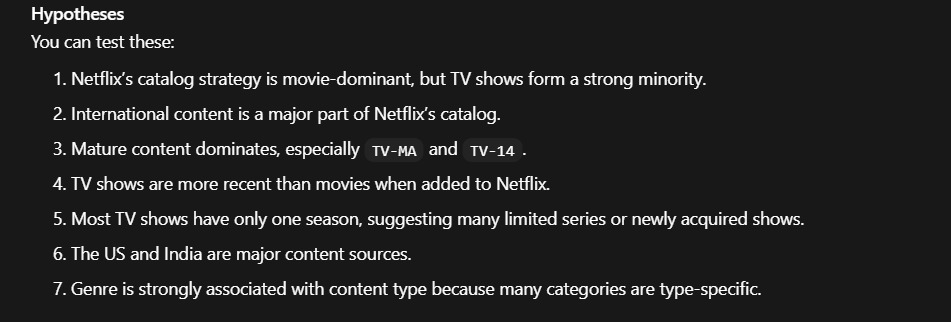

Recommended Preprocessing

Before modeling or dashboarding:


1. Convert date_added to datetime.
2. Extract year_added, month_added, and content_age_when_added.
3. Fix the three rows where rating contains duration.
4. Split duration into duration_minutes for Movies and seasons for TV Shows.
5. Fill missing director, cast, and country with "Unknown".
6. Split country into multiple country rows for country-level analysis.
7. Split listed_in into multiple genre rows for genre-level analysis.
8. Encode type, rating, country, and genre for ML.
9. Avoid using show_id as a predictive feature.
10. For text analysis, clean and vectorize description.

EDA Code

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [27]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [18]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [28]:
import sys
!{sys.executable} -m pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 9.2 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------------------ --------- 2.1/2.7 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 8.8 MB/s eta 0:00:00
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.8/38.1 MB 11.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.5/38.1 MB 12.2 MB/s eta 0:00:03
   ------- -------------------------------- 7.1/38.1 MB 12.1 MB/s eta 0:00:03
   --------- ------------------------------ 9.4/38.1 MB 11.7 MB/s eta 0:00:03
   ----


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
print(df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all").T)

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Missing values
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)
display(missing)

,missing_count,missing_pct
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
release_year,0,0.000000


In [7]:
# Duplicates
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate titles:", df["title"].duplicated().sum())

Duplicate rows: 0
Duplicate titles: 0


In [8]:
# Fix duration stored in rating
mask = df["duration"].isna() & df["rating"].astype(str).str.contains("min", na=False)
df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = np.nan

In [9]:
# Dates
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()
df["content_age_when_added"] = df["year_added"] - df["release_year"]

In [10]:
# Duration
df["duration_num"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"([A-Za-z]+)")

movies = df[df["type"] == "Movie"]
shows = df[df["type"] == "TV Show"]

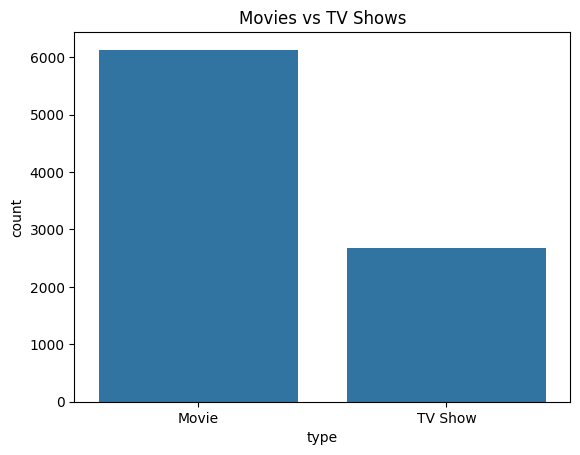

In [11]:
# Type distribution
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.show()

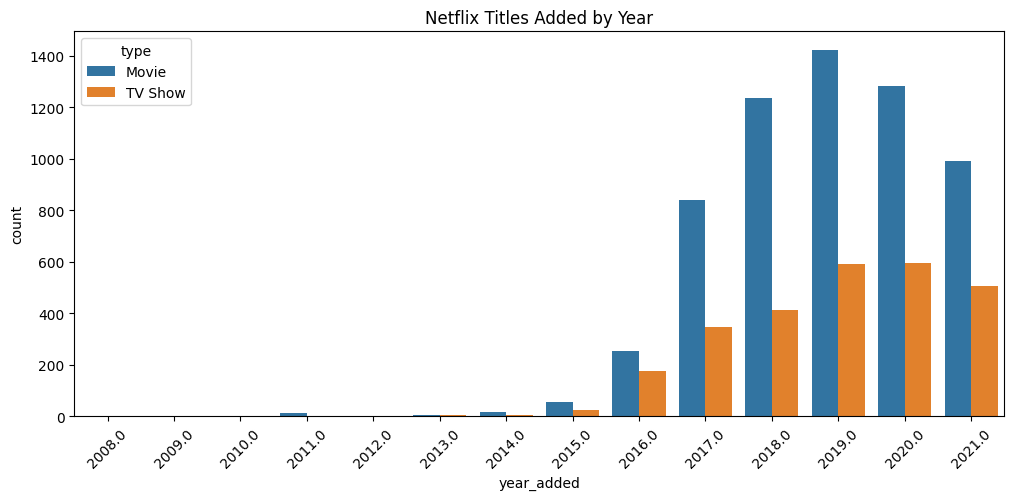

In [12]:
# Titles added by year
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="year_added", hue="type")
plt.xticks(rotation=45)
plt.title("Netflix Titles Added by Year")
plt.show()

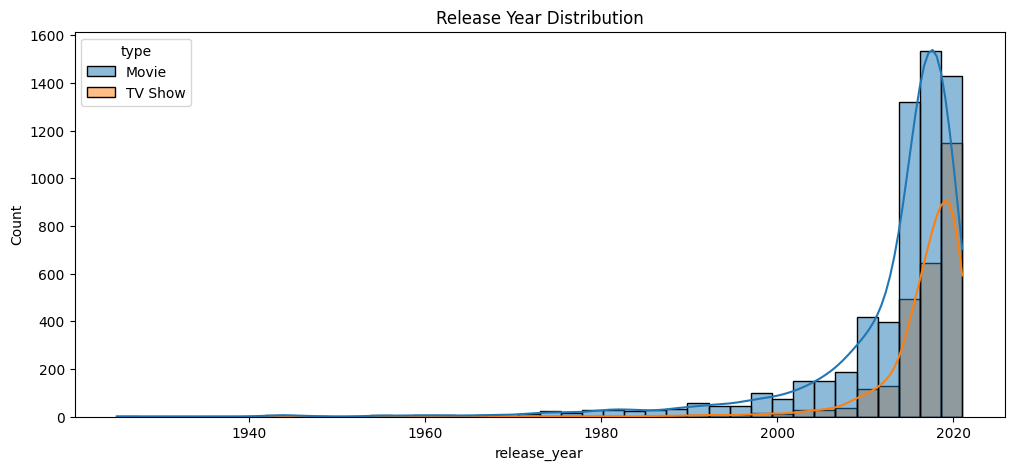

In [13]:
# Release year distribution
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="release_year", hue="type", bins=40, kde=True)
plt.title("Release Year Distribution")
plt.show()

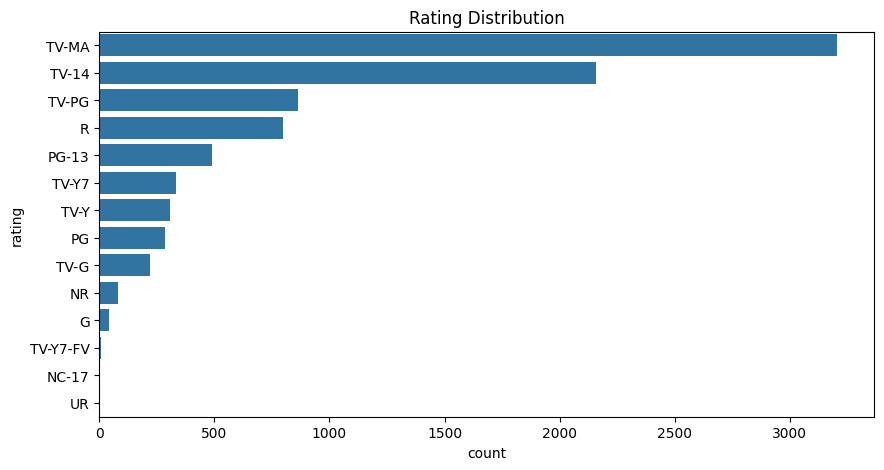

In [14]:
# Ratings
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="rating", order=df["rating"].value_counts().index)
plt.title("Rating Distribution")
plt.show()

In [15]:
# Countries
country_series = df["country"].fillna("Unknown").str.split(", ").explode().str.strip()
top_countries = country_series.value_counts().head(15)

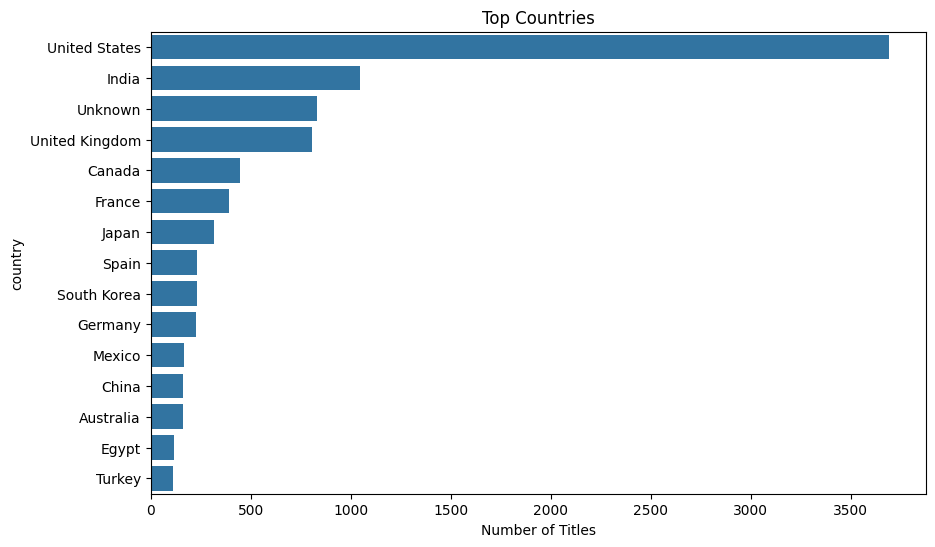

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top Countries")
plt.xlabel("Number of Titles")
plt.show()

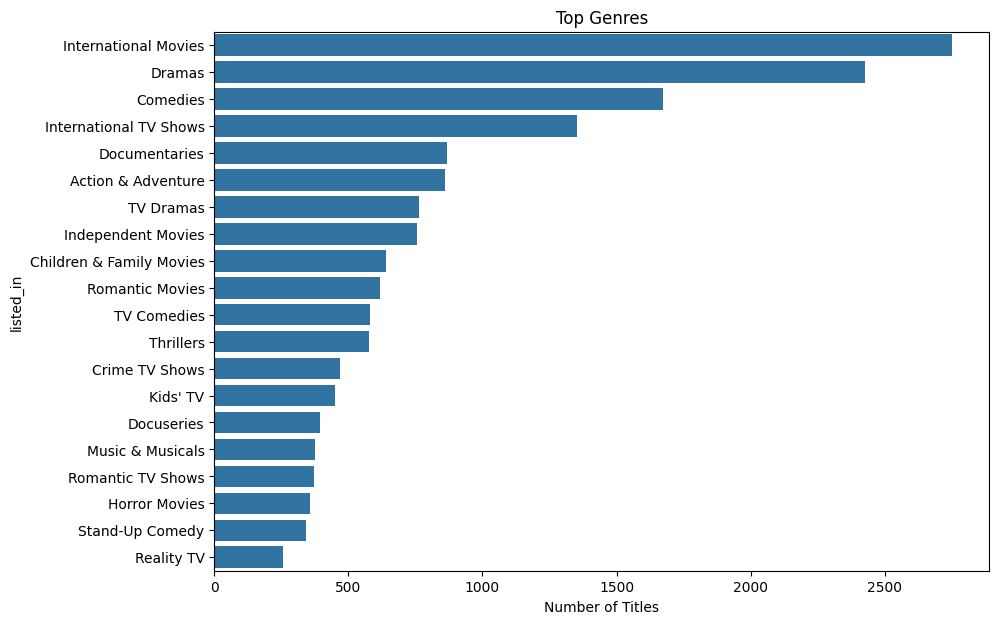

In [17]:
# Genres
genre_series = df["listed_in"].str.split(", ").explode().str.strip()
top_genres = genre_series.value_counts().head(20)
plt.figure(figsize=(10, 7))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top Genres")
plt.xlabel("Number of Titles")
plt.show()

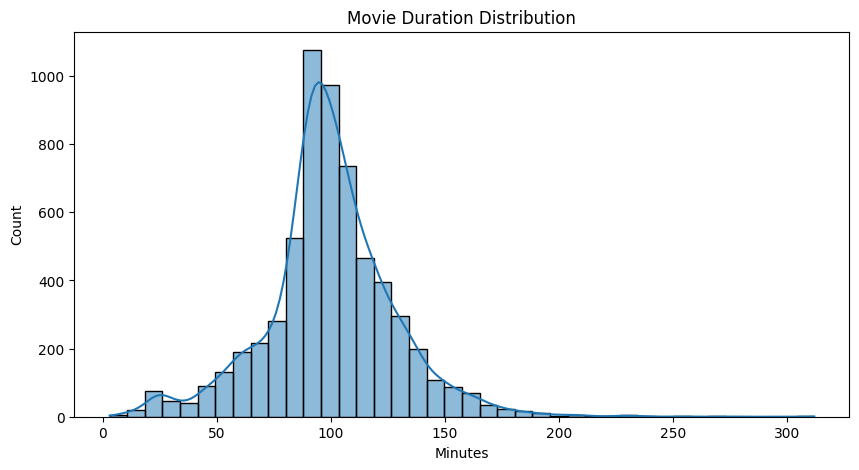

In [18]:
# Movie duration
plt.figure(figsize=(10, 5))
sns.histplot(movies["duration_num"], bins=40, kde=True)
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.show()

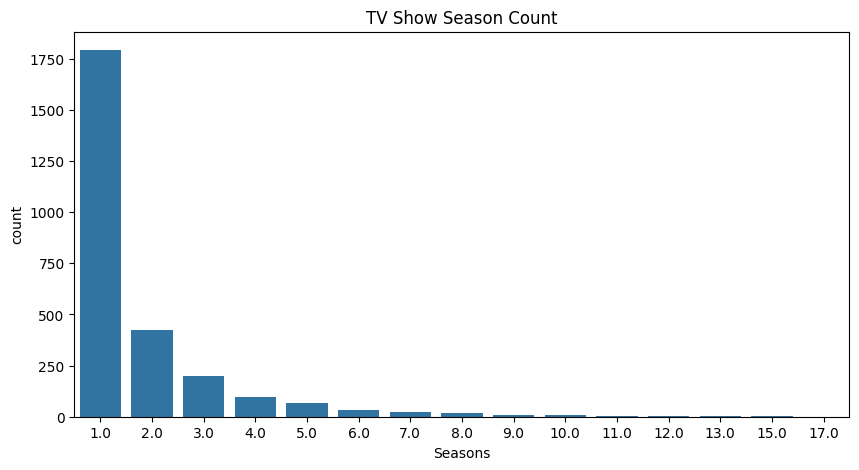

In [19]:
# TV show seasons
plt.figure(figsize=(10, 5))
sns.countplot(data=shows, x="duration_num")
plt.title("TV Show Season Count")
plt.xlabel("Seasons")
plt.show()

In [20]:
# Top directors and actors
top_directors = (
    df["director"].dropna()
    .str.split(", ")
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
)
display(top_directors)

top_cast = (
    df["cast"].dropna()
    .str.split(", ")
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
)
display(top_cast)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Jay Chapman            12
Youssef Chahine        12
Steven Spielberg       11
Don Michael Paul       10
David Dhawan            9
Shannon Hartman         9
Anurag Kashyap          9
Name: count, dtype: int64

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Amitabh Bachchan    28
Boman Irani         27
Vincent Tong        26
Rajesh Kava         26
Andrea Libman       25
Name: count, dtype: int64

In [21]:
# Rating vs type
rating_type = pd.crosstab(df["rating"], df["type"], normalize="index") * 100
display(rating_type.round(2))


type,Movie,TV Show
rating,,
G,100.00,0.00
NC-17,100.00,0.00
NR,93.75,6.25
PG,100.00,0.00
PG-13,100.00,0.00
R,99.75,0.25
TV-14,66.06,33.94
TV-G,57.27,42.73
TV-MA,64.30,35.70


In [22]:
# Genre vs type
genre_type = (
    df.assign(genre=df["listed_in"].str.split(", "))
      .explode("genre")
      .groupby(["genre", "type"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)
display(genre_type.head(30))

,genre,type,count
16,International Movies,Movie,2752
12,Dramas,Movie,2427
7,Comedies,Movie,1674
17,International TV Shows,TV Show,1351
10,Documentaries,Movie,869
0,Action & Adventure,Movie,859
34,TV Dramas,TV Show,763
15,Independent Movies,Movie,756
4,Children & Family Movies,Movie,641
24,Romantic Movies,Movie,616


Insight generation

Trend Analysis

Netflix additions grew sharply from 2015 to 2019, then declined in 2020 and 2021.

2015:   82 titles
2016:  429 titles
2017: 1,188 titles
2018: 1,649 titles
2019: 2,016 titles  ← peak
2020: 1,879 titles
2021: 1,498 titles

This suggests a rapid catalog expansion phase between 2016-2019, followed by a slowdown. The 2021 decline may be partly because the dataset only goes up to September 25, 2021, so 2021 is incomplete.

Movies dominate every recent year, but TV Shows gained share slightly:

2018: Movies 75.0%, TV Shows 25.0%
2019: Movies 70.6%, TV Shows 29.4%
2020: Movies 68.3%, TV Shows 31.7%
2021: Movies 66.3%, TV Shows 33.7%

Group Comparisons

Movies and TV Shows behave differently.


Movies are older when added:

Movie median content age: 2 years
TV Show median content age: 0 years

This means Netflix often adds TV Shows close to their release year, while movies include more older catalog content.

Country patterns are also different:

India:        92.0% Movies, 8.0% TV Shows
Japan:        32.8% Movies, 67.2% TV Shows
South Korea:  22.3% Movies, 77.7% TV Shows
United States: 73.6% Movies, 26.4% TV Shows

This suggests India contributes mostly films, while Japan and South Korea are much more TV/anime/series-oriented in this dataset.

Ratings differ by content type:

R:      99.7% Movies
PG-13: 100.0% Movies
PG:    100.0% Movies
TV-Y7: 58.4% TV Shows
TV-Y:  57.3% TV Shows

Anomalies

Important anomalies:

Three rows have duration stored in rating instead of duration.



Louis C.K. 2017                       rating = 74 min
Louis C.K.: Hilarious                 rating = 84 min
Louis C.K.: Live at the Comedy Store  rating = 66 min


There are 14 titles where release_year is after year_added.
Example:



Sense8: release_year 2018, added 2016
Jack Taylor: release_year 2016, added 2013


These may represent updated seasons, metadata refreshes, or data inconsistencies.

Movie duration outliers exist.

Very long examples:



Black Mirror: Bandersnatch: 312 min
Headspace: Unwind Your Mind: 273 min
The School of Mischief: 253 min


Very short examples:



Silent: 3 min
Sol Levante: 5 min
Cops and Robbers: 8 min
Canvas: 9 min


These are probably interactive titles, shorts, specials, or metadata edge cases.

Director missingness is highly uneven.


Movies missing director: 3.1%
TV Shows missing director: 91.4%


This is not random missingness. Director is much less meaningful for TV Shows than for Movies.

Relationships

type is strongly related to several features:

1. duration: Movies use minutes; TV Shows use seasons.
2. rating: R, PG-13, and PG are movie-heavy.
3. director: mostly available for Movies, mostly missing for TV Shows.
4. country: countries differ in movie-vs-TV mix.
5. listed_in: many genres are type-specific, such as International Movies, TV Dramas, Kids' TV.



content_age relates to type and rating:



TV-MA median age: 0 years
TV-14 median age: 2 years
R median age: 5 years
PG-13 median age: 9 years
G median age: 17 years


This suggests older catalog content is more common among traditional movie ratings, while newer Netflix-era content is often classified under TV-style ratings.

In [23]:
y = df["rating"]

In [24]:
mask = df["duration"].isna() & df["rating"].astype(str).str.contains("min", na=False)
df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = np.nan

df = df.dropna(subset=["rating"])

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier

import shap
import matplotlib.pyplot as plt

path = r"D:\OTHERS\internship_geakminds\day3\netflix_titles.csv"
df = pd.read_csv(path)

# Fix rating-duration data issue
mask = df["duration"].isna() & df["rating"].astype(str).str.contains("min", na=False)
df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = np.nan

# Drop rows without target
df = df.dropna(subset=["rating"]).copy()

# Date features
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df["content_age"] = df["year_added"] - df["release_year"]

# Duration features
df["duration_num"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"([A-Za-z]+)")

# Country features
df["main_country"] = df["country"].fillna("Unknown").str.split(", ").str[0]
df["num_countries"] = df["country"].fillna("").apply(
    lambda x: 0 if x == "" else len(x.split(", "))
)

# Genre features
df["num_genres"] = df["listed_in"].fillna("").apply(
    lambda x: 0 if x == "" else len(x.split(", "))
)

# Director / cast safe features
df["has_director"] = df["director"].notna().astype(int)
df["num_directors"] = df["director"].fillna("").apply(
    lambda x: 0 if x == "" else len(x.split(", "))
)

df["has_cast"] = df["cast"].notna().astype(int)
df["num_cast_members"] = df["cast"].fillna("").apply(
    lambda x: 0 if x == "" else len(x.split(", "))
)

# Text length features, not raw text
df["description_word_count"] = df["description"].fillna("").str.split().str.len()
df["description_char_count"] = df["description"].fillna("").str.len()

# Selected non-leaky features
features = [
    "type",
    "release_year",
    "year_added",
    "month_added",
    "content_age",
    "duration_num",
    "duration_unit",
    "main_country",
    "listed_in",
    "num_countries",
    "num_genres",
    "has_director",
    "num_directors",
    "has_cast",
    "num_cast_members",
    "description_word_count",
    "description_char_count"
]

X = df[features]
y = df["rating"]

categorical_features = [
    "type",
    "duration_unit",
    "main_country",
    "listed_in"
]

numeric_features = [
    "release_year",
    "year_added",
    "month_added",
    "content_age",
    "duration_num",
    "num_countries",
    "num_genres",
    "has_director",
    "num_directors",
    "has_cast",
    "num_cast_members",
    "description_word_count",
    "description_char_count"
]

# Handle missing values
for col in numeric_features:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_features:
    X[col] = X[col].fillna("Unknown")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

c:\Users\harsh\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\harsh\AppData\Local\Temp\ipykernel_16144\343056090.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].median())
C:\Users\harsh\AppData\Local\Temp\ipykernel_16144\343056090.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

Accuracy: 0.46079545454545456
Macro F1: 0.311647097050244
              precision    recall  f1-score   support

           G       0.33      0.62      0.43         8
       NC-17       0.00      0.00      0.00         1
          NR       0.09      0.62      0.16        16
          PG       0.54      0.47      0.50        57
       PG-13       0.41      0.60      0.49        98
           R       0.41      0.56      0.47       160
       TV-14       0.53      0.53      0.53       432
        TV-G       0.08      0.11      0.10        44
       TV-MA       0.71      0.43      0.53       641
       TV-PG       0.28      0.20      0.24       173
        TV-Y       0.46      0.62      0.53        61
       TV-Y7       0.28      0.55      0.37        67
    TV-Y7-FV       0.00      0.00      0.00         1
          UR       0.00      0.00      0.00         1

    accuracy                           0.46      1760
   macro avg       0.30      0.38      0.31      1760
weighted avg       0.5

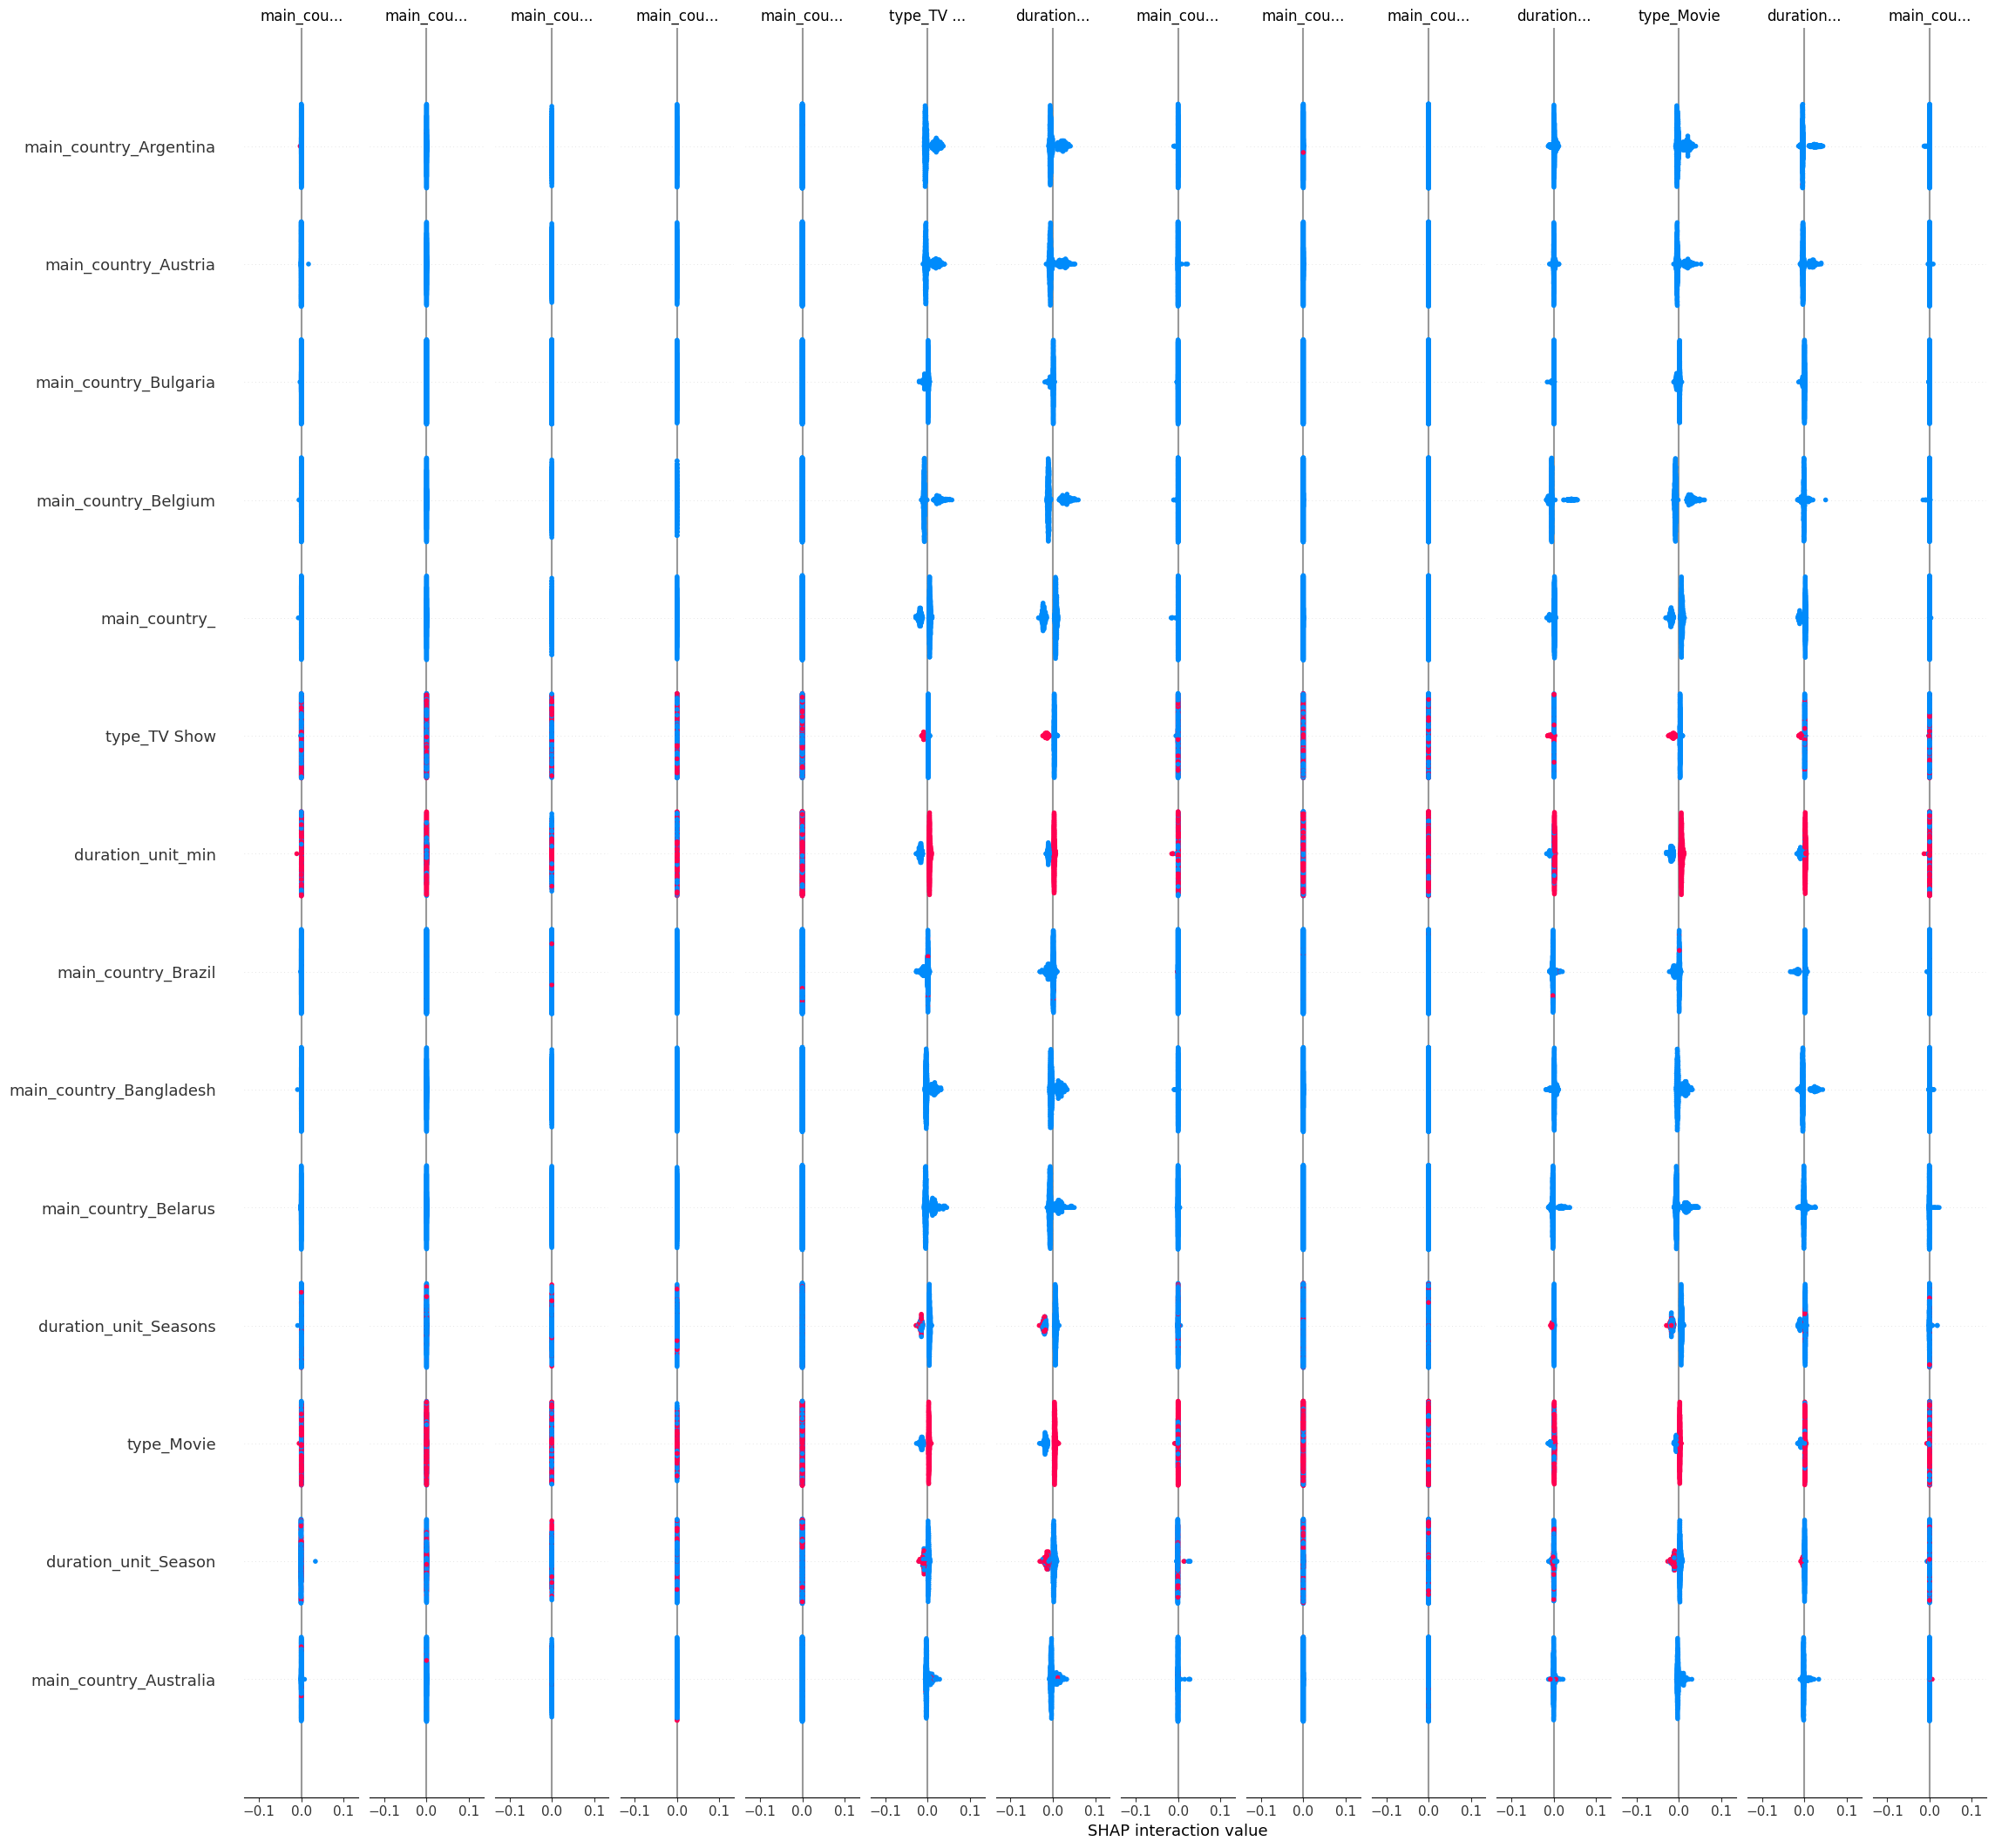

In [30]:
# Transform data after preprocessing
X_train_transformed = pipeline.named_steps["preprocess"].transform(X_train)
X_test_transformed = pipeline.named_steps["preprocess"].transform(X_test)

# Get transformed feature names
cat_names = pipeline.named_steps["preprocess"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

feature_names = list(cat_names) + numeric_features

# Convert sparse matrix to dense for SHAP sample
X_test_sample = X_test_transformed[:500]

if hasattr(X_test_sample, "toarray"):
    X_test_sample = X_test_sample.toarray()

explainer = shap.TreeExplainer(pipeline.named_steps["model"])
shap_values = explainer.shap_values(X_test_sample)

# Global feature importance across all classes
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    max_display=25
)

In [31]:
class_name = "TV-MA"
class_index = list(label_encoder.classes_).index(class_name)

shap.summary_plot(
    shap_values[class_index],
    X_test_sample,
    feature_names=feature_names,
    max_display=25
)

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [33]:
import pandas as pd
import numpy as np
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report


In [34]:

path = r"D:\OTHERS\internship_geakminds\day3\netflix_titles.csv"
df = pd.read_csv(path)


In [35]:

# Fix data issue: duration accidentally stored in rating
mask = df["duration"].isna() & df["rating"].astype(str).str.contains("min", na=False)
df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = np.nan


In [36]:

# Drop missing target
df = df[df["rating"].notna()].copy()


In [37]:

# Feature engineering without target leakage
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df["content_age"] = df["year_added"] - df["release_year"]

df["duration_num"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"([A-Za-z]+)")

df["main_country"] = df["country"].fillna("Unknown").str.split(", ").str[0]
df["num_countries"] = df["country"].fillna("").apply(lambda x: 0 if x == "" else len(x.split(", ")))
df["num_genres"] = df["listed_in"].fillna("").apply(lambda x: 0 if x == "" else len(x.split(", ")))
df["num_cast_members"] = df["cast"].fillna("").apply(lambda x: 0 if x == "" else len(x.split(", ")))

df["has_director"] = df["director"].notna().astype(int)
df["has_cast"] = df["cast"].notna().astype(int)
df["has_country"] = df["country"].notna().astype(int)
df["description_word_count"] = df["description"].fillna("").str.split().str.len()

text_cols = ["listed_in", "country", "director", "cast", "description"]
for col in text_cols:
    df[col] = df[col].fillna("Unknown").astype(str)


In [38]:

# Do not use show_id, title, or rating-derived features
target = "rating"

numeric_features = [
    "release_year", "year_added", "month_added", "content_age",
    "duration_num", "num_countries", "num_genres", "num_cast_members",
    "has_director", "has_cast", "has_country", "description_word_count"
]

categorical_features = [
    "type", "duration_unit", "main_country"
]


In [39]:

X = df[numeric_features + categorical_features + text_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [40]:

comma_tokenizer = lambda s: [x.strip() for x in s.split(",") if x.strip()]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=10), categorical_features),

        ("genres", TfidfVectorizer(
            tokenizer=comma_tokenizer,
            lowercase=False
        ), "listed_in"),

        ("country_multi", TfidfVectorizer(
            tokenizer=comma_tokenizer,
            lowercase=False,
            min_df=3
        ), "country"),

        ("director", TfidfVectorizer(
            token_pattern=r"[^,]+",
            min_df=2,
            max_features=500
        ), "director"),

        ("cast", TfidfVectorizer(
            token_pattern=r"[^,]+",
            min_df=3,
            max_features=1000
        ), "cast"),

        ("desc", TfidfVectorizer(
            stop_words="english",
            min_df=3,
            max_features=3000,
            ngram_range=(1, 2)
        ), "description")
    ]
)


In [41]:

model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="saga",
        n_jobs=-1
    ))
])


In [42]:

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Macro F1:", f1_score(y_test, pred, average="macro"))
print("Weighted F1:", f1_score(y_test, pred, average="weighted"))
print(classification_report(y_test, pred, zero_division=0))


c:\Users\harsh\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Accuracy: 0.5647727272727273
Macro F1: 0.31949391424778967
Weighted F1: 0.5436297382313595
              precision    recall  f1-score   support

           G       0.50      0.12      0.20         8
       NC-17       0.00      0.00      0.00         1
          NR       0.00      0.00      0.00        16
          PG       0.51      0.51      0.51        57
       PG-13       0.54      0.45      0.49        98
           R       0.57      0.59      0.58       160
       TV-14       0.54      0.52      0.53       432
        TV-G       0.00      0.00      0.00        44
       TV-MA       0.61      0.76      0.68       641
       TV-PG       0.38      0.21      0.27       173
        TV-Y       0.62      0.64      0.63        61
       TV-Y7       0.57      0.63      0.60        67
    TV-Y7-FV       0.00      0.00      0.00         1
          UR       0.00      0.00      0.00         1

    accuracy                           0.56      1760
   macro avg       0.35      0.32      0.32

In [43]:

# SHAP
prep = model.named_steps["prep"]
clf = model.named_steps["clf"]

X_train_trans = prep.transform(X_train)
X_test_trans = prep.transform(X_test)
feature_names = prep.get_feature_names_out()

explainer = shap.LinearExplainer(clf, X_train_trans[:300])
shap_values = explainer.shap_values(X_test_trans[:300])

if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(v).mean(axis=0) for v in shap_values], axis=0)
else:
    arr = np.asarray(shap_values)
    mean_abs_shap = np.abs(arr).mean(axis=(0, 2)) if arr.ndim == 3 else np.abs(arr).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
)

print(shap_importance.head(30))

                              feature  mean_abs_shap
4                   num__duration_num       0.686638
13                  cat__type_TV Show       0.433324
8                   num__has_director       0.279523
12                    cat__type_Movie       0.275160
16             cat__duration_unit_min       0.275160
1                     num__year_added       0.264466
64   genres__Children & Family Movies       0.263864
171      country_multi__United States       0.229973
78                   genres__Kids' TV       0.195025
14          cat__duration_unit_Season       0.191192
649                 director__unknown       0.184431
7               num__num_cast_members       0.171996
76       genres__International Movies       0.166833
57    cat__main_country_United States       0.154382
6                     num__num_genres       0.151504
0                   num__release_year       0.124554
2                    num__month_added       0.115237
5                  num__num_countries       0.

In [45]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


path = r"D:\OTHERS\internship_geakminds\day3\netflix_titles.csv"
df = pd.read_csv(path)


def add_features(data):
    data = data.copy()

    data["date_added"] = pd.to_datetime(
        data["date_added"].astype(str).str.strip(),
        errors="coerce"
    )

    data["year_added"] = data["date_added"].dt.year
    data["month_added"] = data["date_added"].dt.month
    data["content_age"] = data["year_added"] - data["release_year"]

    data["duration_num"] = (
        data["duration"].astype(str).str.extract(r"(\d+)").astype(float)
    )
    data["duration_unit"] = data["duration"].astype(str).str.extract(r"([A-Za-z]+)")

    data["main_country"] = data["country"].fillna("Unknown").str.split(", ").str[0]

    data["num_countries"] = data["country"].fillna("").apply(
        lambda x: 0 if x == "" else len([p for p in str(x).split(", ") if p])
    )

    data["num_genres"] = data["listed_in"].fillna("").apply(
        lambda x: 0 if x == "" else len([p for p in str(x).split(", ") if p])
    )

    data["num_cast_members"] = data["cast"].fillna("").apply(
        lambda x: 0 if x == "" else len([p for p in str(x).split(", ") if p])
    )

    data["has_director"] = data["director"].notna().astype(int)
    data["has_cast"] = data["cast"].notna().astype(int)
    data["has_country"] = data["country"].notna().astype(int)

    data["description_word_count"] = (
        data["description"].fillna("").str.split().str.len()
    )

    text_cols = [
        "listed_in",
        "country",
        "director",
        "cast",
        "description",
        "type",
        "duration_unit",
        "main_country"
    ]

    for col in text_cols:
        data[col] = data[col].fillna("Unknown").astype(str)

    return data


# Fix known issue: duration accidentally stored in rating
mask = df["duration"].isna() & df["rating"].astype(str).str.contains("min", na=False)
df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = np.nan

# Drop rows where target is missing
df = df[df["rating"].notna()].copy()

df = add_features(df)

numeric_features = [
    "release_year",
    "year_added",
    "month_added",
    "content_age",
    "duration_num",
    "num_countries",
    "num_genres",
    "num_cast_members",
    "has_director",
    "has_cast",
    "has_country",
    "description_word_count"
]

categorical_features = [
    "type",
    "duration_unit",
    "main_country"
]

text_features = [
    "listed_in",
    "country",
    "director",
    "cast",
    "description"
]

X = df[numeric_features + categorical_features + text_features]
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

comma_tokenizer = lambda s: [x.strip() for x in s.split(",") if x.strip()]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", min_frequency=10),
            categorical_features
        ),

        (
            "genres",
            TfidfVectorizer(
                tokenizer=comma_tokenizer,
                lowercase=False
            ),
            "listed_in"
        ),

        (
            "country_multi",
            TfidfVectorizer(
                tokenizer=comma_tokenizer,
                lowercase=False,
                min_df=3
            ),
            "country"
        ),

        (
            "director",
            TfidfVectorizer(
                token_pattern=r"[^,]+",
                min_df=2,
                max_features=500
            ),
            "director"
        ),

        (
            "cast",
            TfidfVectorizer(
                token_pattern=r"[^,]+",
                min_df=3,
                max_features=1000
            ),
            "cast"
        ),

        (
            "desc",
            TfidfVectorizer(
                stop_words="english",
                min_df=3,
                max_features=3000,
                ngram_range=(1, 2)
            ),
            "description"
        )
    ]
)

model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="saga",
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

test_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_pred))


# Dummy examples
dummy_raw = pd.DataFrame([
    {
        "type": "Movie",
        "title": "Magic Puppy Adventure",
        "director": "Unknown",
        "cast": "Friendly Voice Actor, Child Actor",
        "country": "United States",
        "date_added": "July 15, 2021",
        "release_year": 2021,
        "duration": "82 min",
        "listed_in": "Children & Family Movies, Comedies",
        "description": (
            "A cheerful puppy and two children go on a magical adventure "
            "to save their neighborhood with friendship and courage."
        ),
        "expected_rating": "TV-Y"
    },
    {
        "type": "TV Show",
        "title": "Dark City Crimes",
        "director": "Unknown",
        "cast": "Crime Actor, Drama Actor",
        "country": "United States",
        "date_added": "August 1, 2021",
        "release_year": 2021,
        "duration": "1 Season",
        "listed_in": "Crime TV Shows, TV Dramas, International TV Shows",
        "description": (
            "A violent crime syndicate battles detectives in a gritty city "
            "filled with murder, corruption, drugs and revenge."
        ),
        "expected_rating": "TV-MA"
    },
    {
        "type": "Movie",
        "title": "Last Mission",
        "director": "Action Director",
        "cast": "Action Star, Thriller Actor",
        "country": "United States",
        "date_added": "March 10, 2020",
        "release_year": 2018,
        "duration": "116 min",
        "listed_in": "Action & Adventure, Thrillers",
        "description": (
            "A former soldier returns for one final mission involving brutal "
            "violence, explosions, betrayal and a dangerous conspiracy."
        ),
        "expected_rating": "R"
    }
])

dummy = add_features(dummy_raw)

X_dummy = dummy[numeric_features + categorical_features + text_features]

dummy_pred = model.predict(X_dummy)
dummy_proba = model.predict_proba(X_dummy)
classes = model.classes_

results = []

for i, prediction in enumerate(dummy_pred):
    top_idx = np.argsort(dummy_proba[i])[-5:][::-1]

    top_probs = ", ".join([
        f"{classes[j]}={dummy_proba[i, j]:.3f}"
        for j in top_idx
    ])

    results.append({
        "title": dummy_raw.loc[i, "title"],
        "expected_rating": dummy_raw.loc[i, "expected_rating"],
        "predicted_rating": prediction,
        "match_expected": prediction == dummy_raw.loc[i, "expected_rating"],
        "top_5_probabilities": top_probs
    })

results_df = pd.DataFrame(results)
display(results_df)

Test Accuracy: 0.5647727272727273


,title,expected_rating,predicted_rating,match_expected,top_5_probabilities
0,Magic Puppy Adventure,TV-Y,TV-PG,False,"TV-PG=0.265, PG=0.228, TV-Y=0.160, TV-G=0.133,..."
1,Dark City Crimes,TV-MA,TV-MA,True,"TV-MA=0.918, TV-14=0.081, TV-PG=0.001, TV-G=0...."
2,Last Mission,R,R,True,"R=0.415, TV-MA=0.410, PG-13=0.104, TV-14=0.061..."


In [49]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.8147727272727273
Test Accuracy: 0.5647727272727273


In [50]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [51]:

# -----------------------------
# 1. Load dataset
# -----------------------------

path = r"D:\OTHERS\internship_geakminds\day3\netflix_titles.csv"
df = pd.read_csv(path)

print("Original shape:", df.shape)


Original shape: (8807, 12)


In [52]:

# -----------------------------
# 2. Fix known data issue
# -----------------------------
# Some rows have duration accidentally stored in rating

mask = df["duration"].isna() & df["rating"].astype(str).str.contains("min", na=False)
df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = np.nan

# Drop missing target
df = df[df["rating"].notna()].copy()

print("Shape after dropping missing target:", df.shape)


Shape after dropping missing target: (8800, 12)


In [53]:

# -----------------------------
# 3. Optional: remove very rare rating classes
# -----------------------------
# This reduces noise and overfitting for exact rating prediction

min_class_count = 100

valid_classes = df["rating"].value_counts()
valid_classes = valid_classes[valid_classes >= min_class_count].index

df_exact = df[df["rating"].isin(valid_classes)].copy()

print("Exact rating classes kept:")
print(df_exact["rating"].value_counts())


Exact rating classes kept:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
Name: count, dtype: int64


In [54]:

# -----------------------------
# 4. Optional: create grouped rating target
# -----------------------------
# This is more realistic and can reach better accuracy

def rating_group(r):
    if r in ["TV-Y", "TV-Y7", "TV-Y7-FV", "G"]:
        return "Kids"
    elif r in ["TV-G", "TV-PG", "PG"]:
        return "Family"
    elif r in ["TV-14", "PG-13"]:
        return "Teen"
    elif r in ["TV-MA", "R", "NC-17"]:
        return "Mature"
    else:
        return "Other"

df["rating_group"] = df["rating"].apply(rating_group)

print("Grouped rating distribution:")
print(df["rating_group"].value_counts())


Grouped rating distribution:
rating_group
Mature    4009
Teen      2650
Family    1370
Kids       688
Other       83
Name: count, dtype: int64


In [55]:

# Choose target mode:
# "exact"  -> predicts exact rating labels like TV-MA, TV-14, PG-13
# "group"  -> predicts grouped labels like Mature, Teen, Family, Kids

target_mode = "exact"   # change to "group" if you want higher accuracy

if target_mode == "exact":
    model_df = df_exact.copy()
    target_col = "rating"
else:
    model_df = df.copy()
    target_col = "rating_group"


In [56]:

# -----------------------------
# 5. Feature engineering
# -----------------------------

def add_features(data):
    data = data.copy()

    data["date_added"] = pd.to_datetime(
        data["date_added"].astype(str).str.strip(),
        errors="coerce"
    )

    data["year_added"] = data["date_added"].dt.year
    data["month_added"] = data["date_added"].dt.month
    data["content_age"] = data["year_added"] - data["release_year"]

    data["duration_num"] = (
        data["duration"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

    data["duration_unit"] = (
        data["duration"]
        .astype(str)
        .str.extract(r"([A-Za-z]+)")
    )

    data["main_country"] = (
        data["country"]
        .fillna("Unknown")
        .str.split(", ")
        .str[0]
    )

    data["num_countries"] = data["country"].fillna("").apply(
        lambda x: 0 if x == "" else len([p for p in str(x).split(", ") if p])
    )

    data["num_genres"] = data["listed_in"].fillna("").apply(
        lambda x: 0 if x == "" else len([p for p in str(x).split(", ") if p])
    )

    data["num_cast_members"] = data["cast"].fillna("").apply(
        lambda x: 0 if x == "" else len([p for p in str(x).split(", ") if p])
    )

    data["has_director"] = data["director"].notna().astype(int)
    data["has_cast"] = data["cast"].notna().astype(int)
    data["has_country"] = data["country"].notna().astype(int)

    data["description_word_count"] = (
        data["description"]
        .fillna("")
        .str.split()
        .str.len()
    )

    # Extra non-leaky text indicators from description
    desc = data["description"].fillna("")

    data["has_violence_words"] = desc.str.contains(
        "murder|killer|crime|violent|revenge|war|drug|deadly|death|blood|attack",
        case=False,
        na=False
    ).astype(int)

    data["has_kids_words"] = desc.str.contains(
        "kids|children|family|school|magic|friendship|adventure|princess|toy",
        case=False,
        na=False
    ).astype(int)

    data["has_romance_words"] = desc.str.contains(
        "love|romance|wedding|relationship|couple",
        case=False,
        na=False
    ).astype(int)

    data["is_short_movie"] = (
        (data["type"] == "Movie") &
        (data["duration_num"] < 60)
    ).astype(int)

    data["is_long_movie"] = (
        (data["type"] == "Movie") &
        (data["duration_num"] > 150)
    ).astype(int)

    data["is_recent_release"] = (
        data["release_year"] >= 2018
    ).astype(int)

    data["is_old_catalog"] = (
        data["content_age"] >= 10
    ).astype(int)

    text_cols = [
        "listed_in",
        "country",
        "description",
        "type",
        "duration_unit",
        "main_country"
    ]

    for col in text_cols:
        data[col] = data[col].fillna("Unknown").astype(str)

    return data


model_df = add_features(model_df)


In [57]:

# -----------------------------
# 6. Select features
# -----------------------------
# To reduce overfitting, we exclude:
# show_id -> identifier
# title -> memorization risk
# director/cast text -> high-cardinality memorization risk
# rating-derived features -> leakage

numeric_features = [
    "release_year",
    "year_added",
    "month_added",
    "content_age",
    "duration_num",
    "num_countries",
    "num_genres",
    "num_cast_members",
    "has_director",
    "has_cast",
    "has_country",
    "description_word_count",
    "has_violence_words",
    "has_kids_words",
    "has_romance_words",
    "is_short_movie",
    "is_long_movie",
    "is_recent_release",
    "is_old_catalog"
]

categorical_features = [
    "type",
    "duration_unit",
    "main_country"
]

text_features = [
    "listed_in",
    "country",
    "description"
]

X = model_df[numeric_features + categorical_features + text_features]
y = model_df[target_col]


In [58]:

# -----------------------------
# 7. Train-test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [59]:

# -----------------------------
# 8. Preprocessing pipeline
# -----------------------------

comma_tokenizer = lambda s: [x.strip() for x in s.split(",") if x.strip()]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=20
            ),
            categorical_features
        ),

        (
            "genres",
            TfidfVectorizer(
                tokenizer=comma_tokenizer,
                lowercase=False,
                min_df=5
            ),
            "listed_in"
        ),

        (
            "country_multi",
            TfidfVectorizer(
                tokenizer=comma_tokenizer,
                lowercase=False,
                min_df=10
            ),
            "country"
        ),

        (
            "desc",
            TfidfVectorizer(
                stop_words="english",
                min_df=10,
                max_df=0.8,
                max_features=800,
                ngram_range=(1, 1)
            ),
            "description"
        )
    ]
)


In [60]:

# -----------------------------
# 9. Model
# -----------------------------

model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="saga",
        C=0.2,
        n_jobs=-1
    ))
])


In [61]:

# -----------------------------
# 10. Train model
# -----------------------------

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")
print("Target mode:", target_mode)
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Train Macro F1:", f1_score(y_train, train_pred, average="macro"))
print("Test Macro F1:", f1_score(y_test, test_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, test_pred, zero_division=0))



MODEL PERFORMANCE
Target mode: exact
Train Accuracy: 0.6327708062887639
Test Accuracy: 0.5790080738177624
Train Macro F1: 0.5560385355011386
Test Macro F1: 0.49470079753974655

Classification Report:
              precision    recall  f1-score   support

          PG       0.58      0.63      0.61        57
       PG-13       0.55      0.37      0.44        98
           R       0.57      0.66      0.61       160
       TV-14       0.53      0.49      0.51       432
        TV-G       0.40      0.05      0.08        44
       TV-MA       0.61      0.78      0.68       642
       TV-PG       0.42      0.16      0.23       173
        TV-Y       0.60      0.72      0.66        61
       TV-Y7       0.65      0.61      0.63        67

    accuracy                           0.58      1734
   macro avg       0.55      0.50      0.49      1734
weighted avg       0.56      0.58      0.55      1734



In [62]:

# -----------------------------
# 11. Grid search for better C
# -----------------------------

param_grid = {
    "clf__C": [0.05, 0.1, 0.2, 0.5, 1.0],
    "clf__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n==============================")
print("GRID SEARCH RESULTS")
print("==============================")
print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_model = grid.best_estimator_

best_train_pred = best_model.predict(X_train)
best_test_pred = best_model.predict(X_test)

print("\nBest Model Train Accuracy:", accuracy_score(y_train, best_train_pred))
print("Best Model Test Accuracy:", accuracy_score(y_test, best_test_pred))
print("Best Model Train Macro F1:", f1_score(y_train, best_train_pred, average="macro"))
print("Best Model Test Macro F1:", f1_score(y_test, best_test_pred, average="macro"))

print("\nBest Model Classification Report:")
print(classification_report(y_test, best_test_pred, zero_division=0))



GRID SEARCH RESULTS
Best Params: {'clf__C': 0.2, 'clf__class_weight': None}
Best CV Accuracy: 0.5703193225904112

Best Model Train Accuracy: 0.6327708062887639
Best Model Test Accuracy: 0.5790080738177624
Best Model Train Macro F1: 0.5560385355011386
Best Model Test Macro F1: 0.49470079753974655

Best Model Classification Report:
              precision    recall  f1-score   support

          PG       0.58      0.63      0.61        57
       PG-13       0.55      0.37      0.44        98
           R       0.57      0.66      0.61       160
       TV-14       0.53      0.49      0.51       432
        TV-G       0.40      0.05      0.08        44
       TV-MA       0.61      0.78      0.68       642
       TV-PG       0.42      0.16      0.23       173
        TV-Y       0.60      0.72      0.66        61
       TV-Y7       0.65      0.61      0.63        67

    accuracy                           0.58      1734
   macro avg       0.55      0.50      0.49      1734
weighted avg     

In [63]:

# -----------------------------
# 12. Feature importance
# -----------------------------

prep = best_model.named_steps["prep"]
clf = best_model.named_steps["clf"]

feature_names = prep.get_feature_names_out()
coef_abs = np.mean(np.abs(clf.coef_), axis=0)

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_coef": coef_abs
    })
    .sort_values("mean_abs_coef", ascending=False)
)

print("\n==============================")
print("TOP FEATURES")
print("==============================")
print(feature_importance.head(30))



TOP FEATURES
                              feature  mean_abs_coef
59   genres__Children & Family Movies       1.876386
73                   genres__Kids' TV       1.273136
71       genres__International Movies       0.855570
4                   num__duration_num       0.644665
65              genres__Documentaries       0.601319
20                  cat__type_TV Show       0.600776
85            genres__Stand-Up Comedy       0.470146
70         genres__Independent Movies       0.445647
96                  genres__Thrillers       0.428455
55         genres__Action & Adventure       0.421860
144      country_multi__United States       0.421619
113              country_multi__India       0.418892
35            cat__main_country_India       0.404753
63             genres__Crime TV Shows       0.400514
68       genres__Faith & Spirituality       0.381562
69              genres__Horror Movies       0.370676
72     genres__International TV Shows       0.364984
67                     genres__D

In [64]:

# -----------------------------
# 13. SHAP
# -----------------------------

try:
    import shap

    X_train_trans = prep.transform(X_train)
    X_test_trans = prep.transform(X_test)

    background_size = min(300, X_train_trans.shape[0])
    sample_size = min(300, X_test_trans.shape[0])

    rng = np.random.default_rng(42)

    background_idx = rng.choice(
        X_train_trans.shape[0],
        background_size,
        replace=False
    )

    sample_idx = rng.choice(
        X_test_trans.shape[0],
        sample_size,
        replace=False
    )

    explainer = shap.LinearExplainer(
        clf,
        X_train_trans[background_idx]
    )

    shap_values = explainer.shap_values(
        X_test_trans[sample_idx]
    )

    if isinstance(shap_values, list):
        mean_abs_shap = np.mean(
            [np.abs(v).mean(axis=0) for v in shap_values],
            axis=0
        )
    else:
        arr = np.asarray(shap_values)

        if arr.ndim == 3:
            mean_abs_shap = np.abs(arr).mean(axis=(0, 2))
        else:
            mean_abs_shap = np.abs(arr).mean(axis=0)

    shap_importance = (
        pd.DataFrame({
            "feature": feature_names,
            "mean_abs_shap": mean_abs_shap
        })
        .sort_values("mean_abs_shap", ascending=False)
    )

    print("\n==============================")
    print("TOP SHAP FEATURES")
    print("==============================")
    print(shap_importance.head(30))

except Exception as e:
    print("\nSHAP failed:", e)


TOP SHAP FEATURES
                              feature  mean_abs_shap
4                   num__duration_num       0.546576
20                  cat__type_TV Show       0.235504
8                   num__has_director       0.212531
7               num__num_cast_members       0.210664
59   genres__Children & Family Movies       0.199746
6                     num__num_genres       0.199047
71       genres__International Movies       0.196291
1                     num__year_added       0.194395
17             num__is_recent_release       0.190915
144      country_multi__United States       0.179517
52    cat__main_country_United States       0.147288
23             cat__duration_unit_min       0.125676
19                    cat__type_Movie       0.125676
18                num__is_old_catalog       0.118980
12            num__has_violence_words       0.102688
113              country_multi__India       0.102380
35            cat__main_country_India       0.098706
73                   genres

In [65]:
# -----------------------------
# 14. Test with new dummy examples
# -----------------------------
# Run this after training best_model from the previous code.

dummy_raw = pd.DataFrame([
    {
        "type": "Movie",
        "title": "Tiny Robot Friends",
        "director": "Unknown",
        "cast": "Child Actor, Voice Actor",
        "country": "United States",
        "date_added": "June 12, 2021",
        "release_year": 2021,
        "duration": "70 min",
        "listed_in": "Children & Family Movies, Comedies",
        "description": (
            "A group of friendly robots help children learn teamwork, "
            "kindness, school lessons and friendship through magical adventures."
        ),
        "expected_rating": "TV-Y"
    },
    {
        "type": "TV Show",
        "title": "Bloodline Streets",
        "director": "Unknown",
        "cast": "Crime Actor, Drama Actor",
        "country": "United States",
        "date_added": "September 10, 2020",
        "release_year": 2020,
        "duration": "1 Season",
        "listed_in": "Crime TV Shows, TV Dramas, TV Thrillers",
        "description": (
            "A violent detective investigates murder, drugs, revenge, "
            "corruption and deadly crimes across a dark city."
        ),
        "expected_rating": "TV-MA"
    },
    {
        "type": "Movie",
        "title": "Galaxy Rescue",
        "director": "Action Director",
        "cast": "Action Star, Adventure Actor",
        "country": "United States",
        "date_added": "May 3, 2019",
        "release_year": 2018,
        "duration": "120 min",
        "listed_in": "Action & Adventure, Sci-Fi & Fantasy",
        "description": (
            "A young hero joins a space crew to save the galaxy from danger, "
            "explosions and a powerful enemy."
        ),
        "expected_rating": "PG-13"
    },
    {
        "type": "Movie",
        "title": "Wedding Season Again",
        "director": "Romance Director",
        "cast": "Romance Actor, Comedy Actor",
        "country": "India",
        "date_added": "February 14, 2021",
        "release_year": 2020,
        "duration": "105 min",
        "listed_in": "Comedies, International Movies, Romantic Movies",
        "description": (
            "Two families prepare for a wedding while a young couple discovers "
            "love, romance, friendship and unexpected comedy."
        ),
        "expected_rating": "TV-14"
    },
    {
        "type": "TV Show",
        "title": "Happy Classroom",
        "director": "Unknown",
        "cast": "Voice Actor, Child Actor",
        "country": "Canada",
        "date_added": "January 20, 2021",
        "release_year": 2021,
        "duration": "2 Seasons",
        "listed_in": "Kids' TV, TV Comedies",
        "description": (
            "Children at school learn friendship, sharing, kindness and "
            "problem solving through funny classroom adventures."
        ),
        "expected_rating": "TV-Y7"
    }
])

# Use same feature engineering function from previous code
dummy = add_features(dummy_raw)

X_dummy = dummy[numeric_features + categorical_features + text_features]

dummy_pred = best_model.predict(X_dummy)
dummy_proba = best_model.predict_proba(X_dummy)
classes = best_model.classes_

dummy_results = []

for i, prediction in enumerate(dummy_pred):
    top_idx = np.argsort(dummy_proba[i])[-5:][::-1]

    top_probs = ", ".join([
        f"{classes[j]}={dummy_proba[i, j]:.3f}"
        for j in top_idx
    ])

    dummy_results.append({
        "title": dummy_raw.loc[i, "title"],
        "expected_rating": dummy_raw.loc[i, "expected_rating"],
        "predicted_rating": prediction,
        "match_expected": prediction == dummy_raw.loc[i, "expected_rating"],
        "top_5_probabilities": top_probs
    })

dummy_results_df = pd.DataFrame(dummy_results)

print("\n==============================")
print("DUMMY EXAMPLE PREDICTIONS")
print("==============================")
display(dummy_results_df)


DUMMY EXAMPLE PREDICTIONS


,title,expected_rating,predicted_rating,match_expected,top_5_probabilities
0,Tiny Robot Friends,TV-Y,TV-Y,True,"TV-Y=0.278, PG=0.236, TV-G=0.163, TV-PG=0.117,..."
1,Bloodline Streets,TV-MA,TV-MA,True,"TV-MA=0.693, TV-14=0.280, TV-PG=0.011, TV-G=0...."
2,Galaxy Rescue,PG-13,PG-13,True,"PG-13=0.297, TV-MA=0.250, TV-14=0.193, R=0.189..."
3,Wedding Season Again,TV-14,TV-14,True,"TV-14=0.594, TV-PG=0.208, TV-MA=0.166, TV-G=0...."
4,Happy Classroom,TV-Y7,TV-Y,False,"TV-Y=0.426, TV-G=0.257, TV-Y7=0.198, TV-PG=0.0..."


In [66]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.6327708062887639
Test Accuracy: 0.5790080738177624
